# **Introduction to PyTorch**
## Image Processing and Computer Vision - Lab Session No. 4

Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

Based on the [UvA Deep Learning Course](https://uvadlc.github.io).

## Exercise 1: improve the accuracy

Try to achieve a better accuracy on the validation set by modifying the previous model and manually tuning the hyper-parameters such as the number of epochs, the learning rate, and the number of hidden layers.


Also, add [Batch Normalization](https://arxiv.org/abs/1502.03167). You can find the normalization layers already implemented in PyTorch [here](https://pytorch.org/docs/stable/nn.html#normalization-layers). Use `torch.nn.Sequential` to stack together a block with the following
structure: FC $\rightarrow$ BatchNorm $\rightarrow$ Activation.

You should easily get 80% accuracy on the validation set.


In [ ]:
def get_linear_bn_relu(input_dim, out_dim):
    """Return a Sequential module with a sandwich of Linear, Batch Norm, and ReLU.

    Args:
        input_dim: the number of input features.
        out_dim: the number of the output features.

    Returns: the created Sequential block.
    """
    modules = []
    # ==================================================================== #
    #                         YOUR CODE STARTS HERE                        #
    # ==================================================================== #
    modules.append(nn.Linear(input_dim, out_dim))
    modules.append(nn.BatchNorm1d(out_dim))
    modules.append(nn.ReLU())
    # ==================================================================== #
    #                         YOUR CODE ENDS HERE                          #
    # ==================================================================== #

    return nn.Sequential(*modules)

In [ ]:
class SimpleClassifierBN(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_classes, n_hidden_layers=0):
        super().__init__()

        self.first = get_linear_bn_relu(input_dim, hidden_dim)
        self.last = nn.Linear(hidden_dim, n_classes)

        self.hidden_layers = nn.ModuleList([
            get_linear_bn_relu(hidden_dim, hidden_dim) for i in range(n_hidden_layers)
        ])

    def forward(self, x):
        x = self.first(x)
        for layer in self.hidden_layers:
            x = layer(x)
        x = self.last(x)

        return x

In [ ]:
# ==================================================================== #
#                         YOUR CODE STARTS HERE                        #
# ==================================================================== #
new_model = model = SimpleClassifierBN(
    input_dim,
    hidden_dim,
    n_classes,
    n_hidden_layers=3
)
new_model.to(device)
optimizer = torch.optim.Adam(new_model.parameters(), lr=0.01)
epochs = 25
# ==================================================================== #
#                         YOUR CODE ENDS HERE                          #
# ==================================================================== #

best_val_acc, best_params, best_epoch = train_loop(
    new_model,
    train_dl,
    epochs,
    optimizer,
    val_dl,
    verbose=True)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 0: train loss 1.396 - train acc 0.524 - valid loss 1.185 - valid acc 0.619
Epoch 5: train loss 0.592 - train acc 0.813 - valid loss 0.903 - valid acc 0.713
Epoch 10: train loss 0.463 - train acc 0.853 - valid loss 0.840 - valid acc 0.733
Epoch 15: train loss 0.387 - train acc 0.876 - valid loss 0.853 - valid acc 0.747
Epoch 20: train loss 0.343 - train acc 0.890 - valid loss 0.703 - valid acc 0.792
Best epoch 17, best acc 0.8148


In [ ]:
new_model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

## Exercise 2: confusion matrix
Compute the confusion matrix for the test set. Then, from the confusion matrix, compute the accuracy score.

> **Note:** a confusion matrix $\mathbf{C}$ is such that $\mathbf{C}_{ij}$ is equal to the number of samples known to belong to class $i$ and predicted to belong to class $j$.

In [ ]:
new_model.eval()
confusion_matrix = torch.zeros(n_classes, n_classes, dtype=torch.int)
# ==================================================================== #
#                         YOUR CODE STARTS HERE                        #
# ==================================================================== #
with torch.no_grad():
    for test_data in test_dl:
        imgs, labels = test_data
        imgs = imgs.to(device)
        labels = labels.to(device)

        scores = new_model(imgs)
        preds = torch.argmax(scores, -1)
        for lbl, pred in zip(labels.view(-1), preds.view(-1)):
                confusion_matrix[lbl.int(), pred.int()] += 1

test_acc = (torch.diagonal(confusion_matrix).sum() / confusion_matrix.sum()).item()
# ==================================================================== #
#                         YOUR CODE ENDS HERE                          #
# ==================================================================== #
print(test_acc)

0.7745082974433899


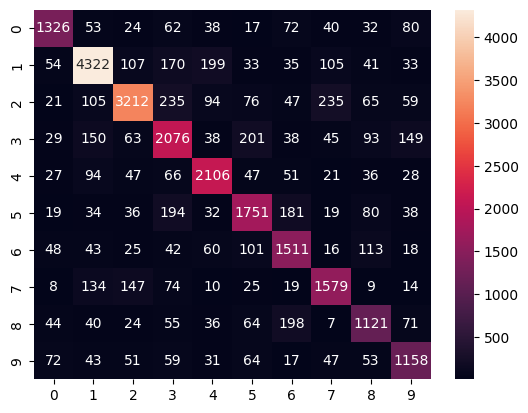

In [ ]:
conf_mtrx_df = pd.DataFrame(confusion_matrix)
sn.heatmap(conf_mtrx_df, annot=True, fmt="d");

## Exercise 3: nearest neighbor search

Rewrite the `forward` method of the classifier class to return the feature vector produced by the network right before the classification scores.

> **Note:** you don't have to retrain the model again!

Then, show the three nearest neighbors in the training set for element with index 0 in the test set.

In [ ]:
class SimpleClassifierBNv2(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_classes, n_hidden_layers=0):
        super().__init__()

        # ==================================================================== #
        #                         YOUR CODE STARTS HERE                        #
        # ==================================================================== #
        self.first = get_linear_bn_relu(input_dim, hidden_dim)
        self.last = nn.Linear(hidden_dim, n_classes)

        self.hidden_layers = nn.ModuleList([
            get_linear_bn_relu(hidden_dim, hidden_dim) for i in range(n_hidden_layers)
        ])
        # ==================================================================== #
        #                         YOUR CODE ENDS HERE                          #
        # ==================================================================== #

    def forward(self, x):
        # ==================================================================== #
        #                         YOUR CODE STARTS HERE                        #
        # ==================================================================== #
        x = self.first(x)
        for layer in self.hidden_layers:
            x = layer(x)

        return x
        # ==================================================================== #
        #                         YOUR CODE ENDS HERE                          #
        # ==================================================================== #

In [ ]:
state_dict = torch.load("best_model.pth")

new_model = SimpleClassifierBNv2(
    input_dim,
    hidden_dim,
    n_classes,
    n_hidden_layers=3
)
new_model.load_state_dict(state_dict)
new_model.to(device)
new_model.eval();

In [ ]:
def get_feat_vecs(model, dl):
    feat_vecs = []
    labels = []
    # ==================================================================== #
    #                         YOUR CODE STARTS HERE                        #
    # ==================================================================== #
    with torch.no_grad():
      for data in dl:
          imgs, lbls = data
          imgs = imgs.to(device)
          lbls = lbls.to(device)

          vecs = model(imgs)

          feat_vecs.append(vecs)
          labels.append(lbls)

    feat_vecs = torch.cat(feat_vecs, dim=0)
    labels = torch.cat(labels, dim=0)
    # ==================================================================== #
    #                         YOUR CODE ENDS HERE                          #
    # ==================================================================== #

    return feat_vecs, labels

train_dl = DataLoader(
    train_subdset,
    batch_size=batch_size,
    shuffle=False  # no shuffle here
)
feat_vecs_train, labels_train = get_feat_vecs(new_model, train_dl)
feat_vecs_test, labels_test = get_feat_vecs(new_model, test_dl)

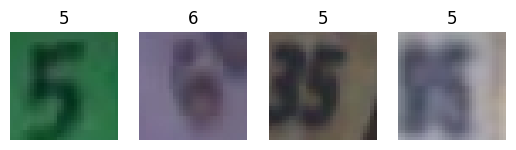

In [ ]:
test_idx = 0

# ==================================================================== #
#                         YOUR CODE STARTS HERE                        #
# ==================================================================== #
feat_vecs_train = F.normalize(feat_vecs_train, dim=1)
feat_vecs_test = F.normalize(feat_vecs_test, dim=1)
feat_vec_test = feat_vecs_test[test_idx].unsqueeze(0)

dist = torch.linalg.norm(feat_vecs_train - feat_vec_test, dim=1)
knn = dist.topk(3, largest=False)

_, ax = plt.subplots(1, 4)
for i in range(4):
    if i == 0:
        img, label = test_dset[test_idx]
    else:
        img, label = train_subdset[knn.indices[i - 1]]
    ax[i].imshow(img.reshape(3, 32, 32).permute(1, 2, 0))
    ax[i].set_title(label)
    ax[i].axis("off")
# ==================================================================== #
#                         YOUR CODE ENDS HERE                          #
# ==================================================================== #